# NB0 · Setup e warm-up

[![Apri in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/battles5/conad-statistical-learning/blob/main/notebooks/NB0_setup.ipynb)

**primo contatto con Colab: gli strumenti, un dataset di ISL, il primo split, la prima previsione**

corso *Apprendimento statistico* per CONAD Nord Ovest · Orso Peruzzi (IFAB)

> come si esegue una cella: clicca dentro e premi **Shift + Invio**; esegui le celle in ordine, dall'alto verso il basso.

in questo primo notebook prendiamo confidenza con l'ambiente e con il flusso di lavoro che useremo tutto il pomeriggio. il dataset e il problema vengono dal capitolo 2 di *Introduction to Statistical Learning* (ISL): prevedere il consumo di un'auto dalle sue caratteristiche.

## 1. gli strumenti

importiamo le librerie che ci accompagneranno:

- `numpy` e `pandas` per i dati;
- `matplotlib` per i grafici;
- `scikit-learn` per i modelli.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("tutto pronto. versione di pandas:", pd.__version__)

tutto pronto. versione di pandas: 3.0.3


## 2. carichiamo un dataset

usiamo **Auto**, uno dei dataset canonici di ISL: consumo e caratteristiche di 392 automobili. lo leggiamo direttamente da un URL, senza scaricare nulla sul computer.

In [2]:
URL = "https://raw.githubusercontent.com/battles5/conad-statistical-learning/main/data/Auto.csv"
auto = pd.read_csv(URL)
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


la colonna `horsepower` (cavalli) contiene qualche valore mancante segnato con `?`. la rendiamo numerica e togliamo le righe incomplete: e' la prima, immancabile, pulizia dei dati.

In [3]:
auto["horsepower"] = pd.to_numeric(auto["horsepower"], errors="coerce")
auto = auto.dropna(subset=["horsepower", "mpg"]).reset_index(drop=True)
print("righe utilizzabili:", len(auto))

righe utilizzabili: 392


## 3. dalle unita' americane al sistema internazionale

il dataset ISL usa unita' di misura americane (miglia per gallone, libbre, pollici cubi, cavalli). le convertiamo nel sistema internazionale, piu' familiare in Italia:

- consumo in **litri per 100 km** (al posto delle miglia per gallone);
- potenza in **kilowatt** (al posto dei cavalli; in Italia spesso indicata anche in CV);
- peso in **kg** (al posto delle libbre);
- cilindrata in **litri** (al posto dei pollici cubi).

In [4]:
auto["consumo"]      = 235.215 / auto["mpg"]            # mpg  -> litri/100 km
auto["potenza_kw"]   = auto["horsepower"] * 0.7457      # hp   -> kilowatt
auto["peso_kg"]      = auto["weight"] * 0.453592        # libbre -> kg
auto["cilindrata_l"] = auto["displacement"] * 0.0163871 # pollici cubi -> litri
auto[["consumo", "potenza_kw", "peso_kg", "cilindrata_l"]].head().round(1)

,consumo,potenza_kw,peso_kg,cilindrata_l
0,13.1,96.9,1589.4,5.0
1,15.7,123.0,1675.1,5.7
2,13.1,111.9,1558.5,5.2
3,14.7,111.9,1557.2,5.0
4,13.8,104.4,1564.4,4.9


## 4. uno sguardo ai dati

`describe()` riassume ogni colonna numerica: media, minimo, quartili, massimo. e' il modo piu' rapido per farsi un'idea degli ordini di grandezza.

In [5]:
auto[["consumo", "potenza_kw", "peso_kg", "year"]].describe().round(1)

,consumo,potenza_kw,peso_kg,year
count,392.0,392.0,392.0,392.0
mean,11.2,77.9,1350.6,76.0
std,3.9,28.7,385.3,3.7
min,5.0,34.3,731.6,70.0
25%,8.1,55.9,1009.4,73.0
50%,10.3,69.7,1271.6,76.0
75%,13.8,94.0,1639.6,79.0
max,26.1,171.5,2331.5,82.0


disegniamo la relazione che studieremo nel prossimo notebook: il consumo (litri/100 km) contro la potenza (kW). e' la stessa relazione della figura 3.8 di ISL, qui in unita' europee.

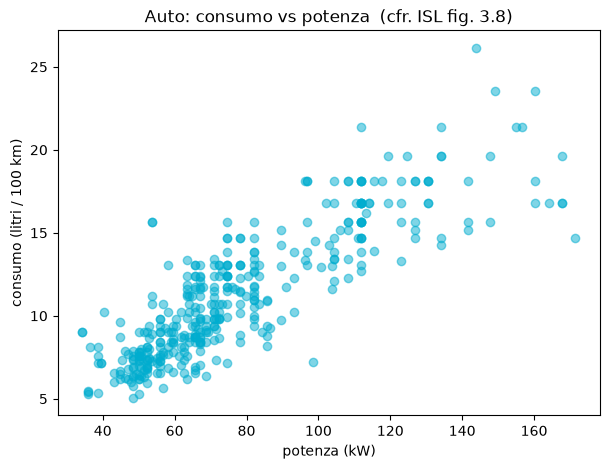

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(auto["potenza_kw"], auto["consumo"], alpha=0.5, color="#00ADCF")
plt.xlabel("potenza (kW)")
plt.ylabel("consumo (litri / 100 km)")
plt.title("Auto: consumo vs potenza  (cfr. ISL fig. 3.8)")
plt.show()

si vede una relazione crescente e **curva**: piu' potenza, piu' consumo, ma non in modo perfettamente lineare. ce ne ricorderemo nel prossimo notebook.

## 5. training set e test set

il principio chiave del mattino: si allena il modello su una parte dei dati e lo si valuta su dati **mai visti**. `train_test_split` fa esattamente questa divisione.

> **manopola**: cambia `TEST_SIZE` (per esempio 0.2, 0.5) e riesegui. quante righe finiscono nei due insiemi?

In [7]:
# >>> MANOPOLA: quota di dati riservata al test set <<<
TEST_SIZE = 0.30

train, test = train_test_split(auto, test_size=TEST_SIZE, random_state=0)
print("righe di training:", len(train))
print("righe di test:    ", len(test))

righe di training: 274
righe di test:     118


## 6. la previsione piu' banale: la media

prima di costruire qualsiasi modello, chiediamoci: quanto sbaglia un "modello" che prevede sempre il **consumo medio**? e' la linea di base (baseline) da battere. impariamo la media **solo** dal training e la usiamo come previsione sul test.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

media_consumo = train["consumo"].mean()             # la media stimata SOLO sul training
pred = np.full(len(test), media_consumo)            # prevediamo sempre quella media
mae = mean_absolute_error(test["consumo"], pred)
rmse = mean_squared_error(test["consumo"], pred) ** 0.5   # radice dell'MSE

print(f"previsione costante: {media_consumo:.1f} litri/100 km")
print(f"errore medio assoluto (MAE) sul test: {mae:.2f} litri/100 km")
print(f"radice dell'MSE (RMSE) sul test:      {rmse:.2f} litri/100 km")

previsione costante: 11.4 litri/100 km
errore medio assoluto (MAE) sul test: 3.19 litri/100 km
radice dell'MSE (RMSE) sul test:      3.83 litri/100 km


tieni a mente questi numeri: nel prossimo notebook vedremo di quanto un vero modello batte questa baseline, e cosa succede se lo rendiamo troppo flessibile.

---

### cella bonus (per i piu' esperti)

la potenza non e' l'unica variabile legata al consumo. il **peso** e' un altro forte predittore: guardiamo la relazione e confrontiamo le due correlazioni.

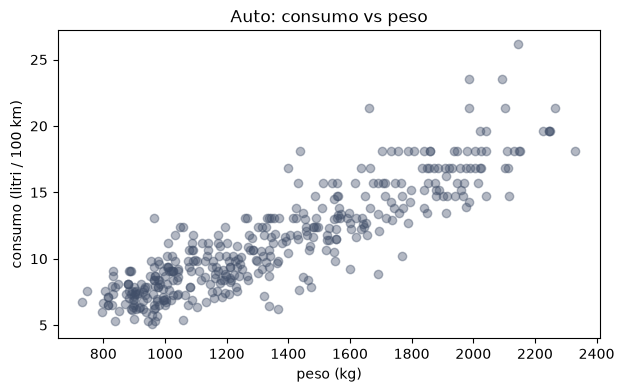

correlazione consumo-potenza: 0.85
correlazione consumo-peso:    0.89


In [9]:
# BONUS
plt.figure(figsize=(7, 4))
plt.scatter(auto["peso_kg"], auto["consumo"], alpha=0.4, color="#414F69")
plt.xlabel("peso (kg)"); plt.ylabel("consumo (litri / 100 km)"); plt.title("Auto: consumo vs peso")
plt.show()

print("correlazione consumo-potenza:", round(auto["consumo"].corr(auto["potenza_kw"]), 2))
print("correlazione consumo-peso:   ", round(auto["consumo"].corr(auto["peso_kg"]), 2))